## Chapter 11

## Poverty Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

poverty = pd.read_csv("poverty.txt", sep="\t")
poverty.head()


,State,Metropolitan Residence,White,Graduates,Poverty,PercentFemaleHouseholderNoHusbandPresent
0,Alabama,55.4,71.3,79.9,14.6,14.2
1,Alaska,65.6,70.8,90.6,8.3,10.8
2,Arizona,88.2,87.7,83.8,13.3,11.1
3,Arkansas,52.5,81.0,80.9,18.0,12.1
4,California,94.4,77.5,81.1,12.8,12.6


Plot the data

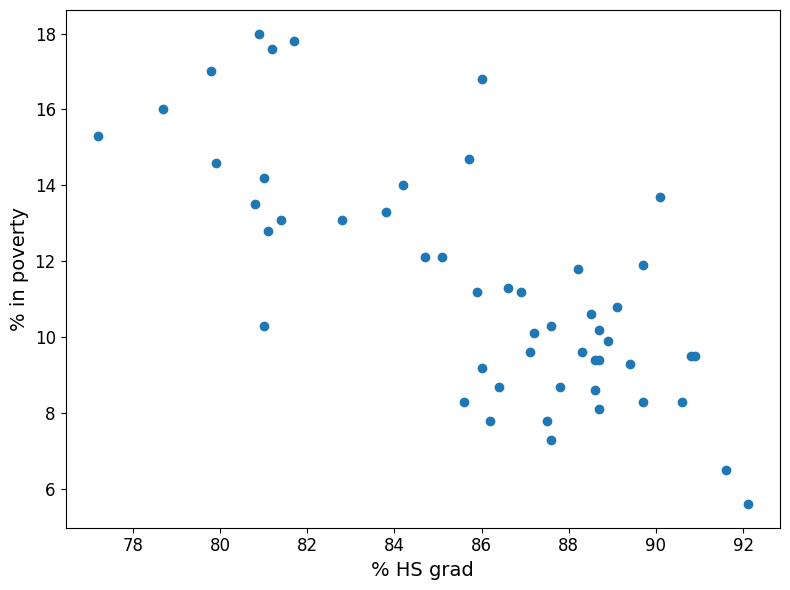

Build linear regression model

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Poverty   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     61.81
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           3.11e-10
Time:                        10:39:45   Log-Likelihood:                -108.74
No. Observations:                  51   AIC:                             221.5
Df Residuals:                      49   BIC:                             225.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.7810      6.803      9.523      0.000      51.111      78.451
Graduates     -0.6212      0.079     -7.862      0.000      -0.780      -0.462
==============================================================================
Omnibus:                        3.534   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.171   Jarque-Bera (JB):                2.653
Skew:                           0.540   Prob(JB):                        0.265
Kurtosis:                       3.289   Cond. No.                     2.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Plot results

Plot the regression line

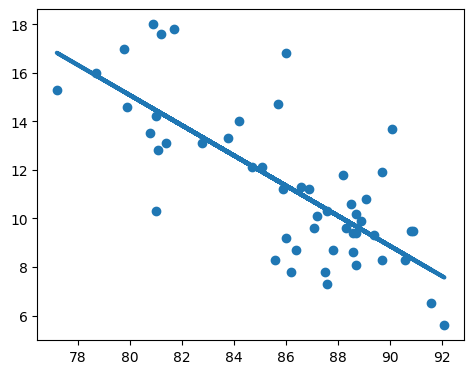

## Scatterplot: % in poverty vs. % female householder, no husband present

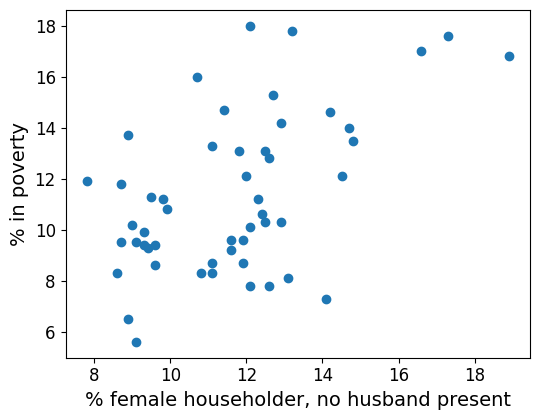

Plot the residuals

Text(0, 0.5, 'Residuals')

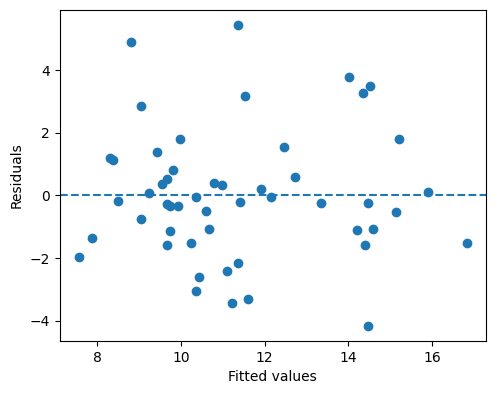

## Twins Example

In [16]:
# Replace with your actual file path if needed
twins = pd.read_csv("twins.csv")
twins.head()



,rownames,foster,biological
0,1,82,82
1,2,80,90
2,3,88,91
3,4,108,115
4,5,116,115


Correlation

In [17]:
r = twins["foster"].corr(twins["biological"])
r

np.float64(0.881987665305972)

Fit linear regression

In [18]:
X = sm.add_constant(twins["biological"])
y = twins["foster"]

m1 = sm.OLS(y, X).fit()

m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 foster   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     87.56
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.20e-09
Time:                        10:39:45   Log-Likelihood:                -92.488
No. Observations:                  27   AIC:                             189.0
Df Residuals:                      25   BIC:                             191.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2076      9.300      0.990      0.332      -9.946      28.361
biological     0.9014      0.096      9.358      0.000       0.703       1.100
==============================================================================
Omnibus:                        0.900   Durbin-Watson:                   1.766
Prob(Omnibus):                  0.638   Jarque-Bera (JB):                0.892
Skew:                           0.373   Prob(JB):                        0.640
Kurtosis:                       2.514   Cond. No.                         604.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
# Create x-grid for smooth line and intervals
newX = np.linspace(
    twins["biological"].min(),
    twins["biological"].max(),
    100
)

X_new = sm.add_constant(newX)

# Predictions and intervals
pred = m1.get_prediction(X_new)
pred_summary = pred.summary_frame(alpha = 0.05)
pred_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,70.505247,3.021104,64.283166,76.727328,53.413756,87.596738
1,71.078888,2.967901,64.966382,77.191394,54.026982,88.130794
2,71.652529,2.915015,65.648943,77.656116,54.639363,88.665695
3,72.226170,2.862466,66.330812,78.121529,55.250894,89.201447
4,72.799811,2.810271,67.011950,78.587672,55.861568,89.738055
...,...,...,...,...,...,...
95,125.001151,3.523598,117.744165,132.258136,107.506334,142.495967
96,125.574792,3.579264,118.203160,132.946424,108.032109,143.117475
97,126.148433,3.635111,118.661781,133.635085,108.557108,143.739758
98,126.722074,3.691132,119.120046,134.324102,109.081337,144.362811


Plot confidence interval

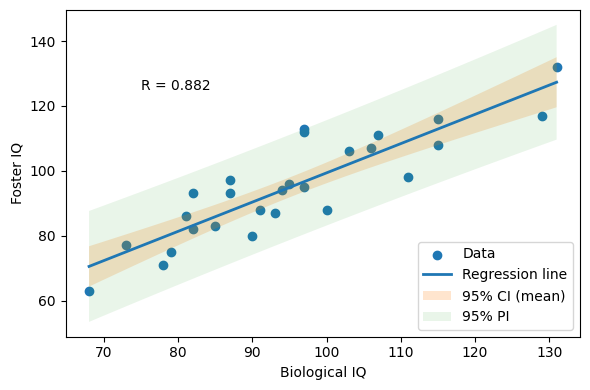

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Scatter
ax.scatter(
    twins["biological"],
    twins["foster"],
    label="Data"
)

# Regression line
ax.plot(
    newX,
    pred_summary["mean"],
    linewidth=2,
    label="Regression line"
)

# Confidence interval for mean response
ax.fill_between(
    newX,
    pred_summary["mean_ci_lower"],
    pred_summary["mean_ci_upper"],
    alpha=0.2, # this is transparency
    label="95% CI (mean)"
)

# Prediction interval for individual response
ax.fill_between(
    newX,
    pred_summary["obs_ci_lower"],
    pred_summary["obs_ci_upper"],
    alpha=0.1, # this is transparency
    label="95% PI"
)

ax.set_xlabel("Biological IQ")
ax.set_ylabel("Foster IQ")
ax.text(75, 125, f"R = {r:.3f}")
ax.legend()

plt.tight_layout()
plt.show()